# LAB-D1-04 SOLUTION: Build a Network That Thinks Forward / Forward Network Mystery

**INSTRUCTOR ONLY - DO NOT DISTRIBUTE WITH PARTICIPANT MATERIALS**

**Canonical objectives:** `OBJ-D1-06`, `OBJ-D1-07` (retrieves `OBJ-D1-04`, `OBJ-D1-05`)  
**Reference environment:** local CPU; Python 3.11+; no network, download, or GPU  
**Expected compute runtime:** under 20 seconds (reference validation records wall time separately)  
**Execution contract:** Restart Kernel -> Run All; this notebook is standalone.

This solution preserves the participant sequence and completes every prediction, implementation,
diagnosis, reflection, deliberate failure, and practical extension. Labeled instructor answers sit
beside the corresponding prompts. Stored outputs are reference evidence from the clean validation run,
not promises that every supported environment will render identical timings or pixels.


In [1]:
import copy
import platform

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import sklearn
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

SEED = 41
plt.rcParams.update({"figure.figsize": (8, 5), "axes.grid": True, "grid.alpha": 0.22})
print(f"Python {platform.python_version()} | NumPy {np.__version__} | matplotlib {matplotlib.__version__} | scikit-learn {sklearn.__version__}")
print("Runtime target: local/Colab CPU; no network or GPU required.")

Python 3.11.8 | NumPy 2.4.6 | matplotlib 3.11.1 | scikit-learn 1.9.0
Runtime target: local/Colab CPU; no network or GPU required.


## Observe: Seeded Moons and a Fixed Evidence Split

The data contains two noisy interleaving arcs. The fixed stratified split records which examples were available during the offline parameter-fitting process and which examples are used for held-out investigation here. This participant notebook never fits a model.

Class is encoded by marker and color. Six held-out examples receive neutral names so you can track them across every panel.

In [2]:
X_all, y_all = make_moons(n_samples=300, noise=0.27, random_state=SEED)
all_indices = np.arange(len(X_all))
train_indices, evidence_indices = train_test_split(
    all_indices, test_size=0.30, random_state=SEED, stratify=y_all
)
X_train, y_train = X_all[train_indices], y_all[train_indices]
X_evidence, y_evidence = X_all[evidence_indices], y_all[evidence_indices]

probe_indices = np.array([4, 127, 265, 228, 273, 181])
probe_names = np.array(["west-window", "lower-gate", "upper-arc", "center-step", "east-rim", "east-notch"])
assert set(probe_indices).issubset(set(evidence_indices))
X_probes = X_all[probe_indices]
y_probes = y_all[probe_indices]

assert X_train.shape == (210, 2) and X_evidence.shape == (90, 2)
assert X_probes.shape == (6, 2) and y_probes.shape == (6,)
print("Data ready: 210 offline-fit examples, 90 held-out evidence examples, 6 named probes.")

Data ready: 210 offline-fit examples, 90 held-out evidence examples, 6 named probes.


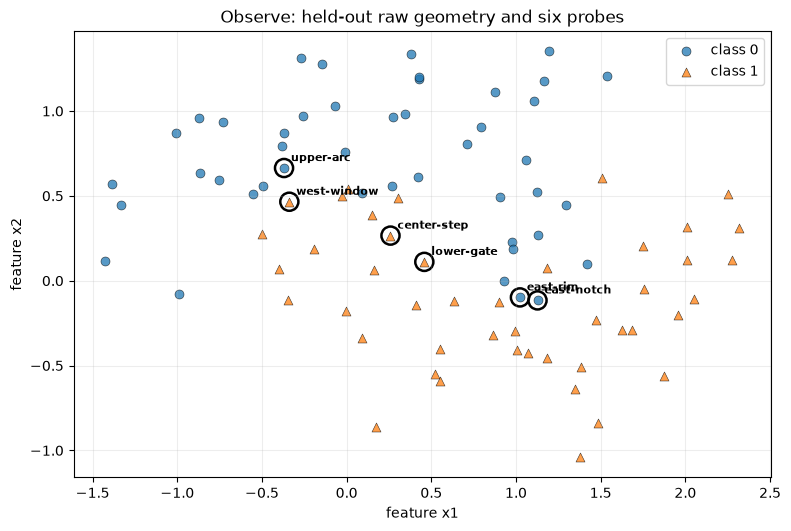

probe                x1       x2   target
west-window      -0.338    0.465        1
lower-gate        0.459    0.111        1
upper-arc        -0.370    0.664        0
center-step       0.259    0.266        1
east-rim          1.023   -0.098        0
east-notch        1.127   -0.116        0


In [3]:
CLASS_STYLES = [(0, "o", "class 0"), (1, "^", "class 1")]


def scatter_classes(ax, X, y, title, alpha=0.75):
    for label, marker, name in CLASS_STYLES:
        mask = y == label
        ax.scatter(X[mask, 0], X[mask, 1], marker=marker, s=42, edgecolor="black", linewidth=0.4, alpha=alpha, label=name)
    ax.set(xlabel="feature x1", ylabel="feature x2", title=title)
    ax.legend()


def annotate_probes(ax, coordinates):
    for name, point in zip(probe_names, coordinates):
        ax.scatter(*point, s=170, facecolors="none", edgecolors="black", linewidths=1.8)
        ax.annotate(name, point, xytext=(5, 5), textcoords="offset points", fontsize=8, weight="bold")


fig, ax = plt.subplots(figsize=(9, 5.8))
scatter_classes(ax, X_evidence, y_evidence, "Observe: held-out raw geometry and six probes")
annotate_probes(ax, X_probes)
plt.show()

print(f"{'probe':<14} {'x1':>8} {'x2':>8} {'target':>8}")
for name, point, target in zip(probe_names, X_probes, y_probes):
    print(f"{name:<14} {point[0]:>8.3f} {point[1]:>8.3f} {target:>8d}")

## Predict Before the Fixed-Parameter Reveal

From raw geometry alone, choose exactly two named probes you think the fixed network will classify incorrectly. Predict hidden and output shapes for a batch of 90 examples. State whether you expect a two-dimensional hidden view to clarify every point or only most points, and name evidence that could make you revise your story.

In [4]:
likely_failure_probes = ["east-rim", "east-notch"]
forward_predictions = {
    "hidden_shape_for_90": "(90,6)",
    "output_shape_for_90": "(90,1)",
    "hidden_view_expectation": "A two-dimensional projection should clarify most, not necessarily every, point.",
    "revision_evidence": "Probe probabilities, the decision contour, and hidden/output trace values can revise the raw-geometry story.",
}
assert len(likely_failure_probes) == 2 and len(set(likely_failure_probes)) == 2
assert set(likely_failure_probes).issubset(set(probe_names))
assert all(value.strip() for value in forward_predictions.values())
print("Instructor prediction:", likely_failure_probes, forward_predictions)


Instructor prediction: ['east-rim', 'east-notch'] {'hidden_shape_for_90': '(90,6)', 'output_shape_for_90': '(90,1)', 'hidden_view_expectation': 'A two-dimensional projection should clarify most, not necessarily every, point.', 'revision_evidence': 'Probe probabilities, the decision contour, and hidden/output trace values can revise the raw-geometry story.'}


### Instructor Answer and Hint Ladder

The reproducible wrong probes are `east-rim` and `east-notch`; predicting both from raw geometry is a
strong answer, but the participant prediction is assessed for reasoning before reveal, not hindsight.
Expected batch shapes are hidden `(90,6)` and output `(90,1)`.

**Hints before reveal:** (1) Look for noisy/boundary locations. (2) State only two names. (3) Write the
architecture widths over the batch dimension. (4) Ask what raw geometry cannot know about fixed weights.

**Common wrong answer:** A hidden 2D view must separate every point. It is a projection of six hidden
dimensions and can omit relationships.


## Observe: Fixed `2 -> 6 -> 1` Parameters

These values were fitted offline on the supplied training split and are fixed for this investigation. The hidden activation is tanh and the binary output uses sigmoid with threshold `0.5`. Keep the canonical dictionary unchanged.

In [5]:
parameters = {
    "W1": np.array([
        [-0.16618268, -0.65779348, 3.31297856, -4.42433680, 2.39102480, 5.51100765],
        [-4.92828506, 4.17901840, -2.65367289, -1.22690598, 5.44204936, -0.31550093],
    ]),
    "b1": np.array([4.15543050, 1.15426212, -1.37874150, -1.76356714, -1.36201945, -7.98641624]),
    "W2": np.array([[4.42064156], [-3.64026782], [-3.12646121], [-6.86956055], [-2.85291978], [5.85951811]]),
    "b2": np.array([-0.79449932]),
}
parameter_snapshot = {name: values.copy() for name, values in parameters.items()}
assert parameters['W1'].shape == (2, 6) and parameters['b1'].shape == (6,)
assert parameters['W2'].shape == (6, 1) and parameters['b2'].shape == (1,)
print("Fixed parameter shapes:", {name: values.shape for name, values in parameters.items()})

Fixed parameter shapes: {'W1': (2, 6), 'b1': (6,), 'W2': (6, 1), 'b2': (1,)}


## Modify: Complete the Vectorized Forward Pass

Complete only the marked TODO bodies. Use batch-first matrix operations; do not loop over examples. `batch_forward` must return a cache with `X`, `Z1`, `A1`, `Z2`, and `P`, where `P` has shape `(n, 1)`.

In [6]:
def stable_sigmoid(values):
    values = np.asarray(values, dtype=float)
    result = np.empty_like(values)
    nonnegative = values >= 0
    result[nonnegative] = 1.0 / (1.0 + np.exp(-values[nonnegative]))
    exp_values = np.exp(values[~nonnegative])
    result[~nonnegative] = exp_values / (1.0 + exp_values)
    return result


def hidden_step(X, parameters):
    X = np.asarray(X, dtype=float)
    Z1 = X @ parameters["W1"] + parameters["b1"]
    A1 = np.tanh(Z1)
    return Z1, A1


def output_step(A1, parameters):
    A1 = np.asarray(A1, dtype=float)
    Z2 = A1 @ parameters["W2"] + parameters["b2"]
    P = stable_sigmoid(Z2)
    return Z2, P


def batch_forward(X, parameters):
    X = np.asarray(X, dtype=float)
    Z1, A1 = hidden_step(X, parameters)
    Z2, P = output_step(A1, parameters)
    return {"X": X, "Z1": Z1, "A1": A1, "Z2": Z2, "P": P}


def predict_classes(probabilities, threshold=0.5):
    probabilities = np.asarray(probabilities)
    if probabilities.ndim != 2 or probabilities.shape[1] != 1:
        raise ValueError(f"Expected probabilities (n,1); got {probabilities.shape}")
    return (probabilities[:, 0] >= float(threshold)).astype(int)


In [7]:
evidence_cache = batch_forward(X_evidence, parameters)
evidence_predictions = predict_classes(evidence_cache['P'])
evidence_accuracy = np.mean(evidence_predictions == y_evidence)
probe_cache = batch_forward(X_probes, parameters)
probe_predictions = predict_classes(probe_cache['P'])
probe_correct = probe_predictions == y_probes

assert evidence_cache['Z1'].shape == evidence_cache['A1'].shape == (90, 6)
assert evidence_cache['Z2'].shape == evidence_cache['P'].shape == (90, 1)
assert np.all(np.isfinite(evidence_cache['P']))
assert np.all((0.0 <= evidence_cache['P']) & (evidence_cache['P'] <= 1.0))
assert evidence_predictions.shape == (90,)
print(f"Held-out accuracy: {evidence_accuracy:.4f}")
print("Evidence shapes:", {name: value.shape for name, value in evidence_cache.items()})

Held-out accuracy: 0.9111
Evidence shapes: {'X': (90, 2), 'Z1': (90, 6), 'A1': (90, 6), 'Z2': (90, 1), 'P': (90, 1)}


### Instructor Reference Result

**Expected deterministic value:** held-out accuracy `0.9111`, inside the canonical `0.82-0.92` band.
Hidden/output shapes are `(90,6)` and `(90,1)`; all probabilities are finite in `[0,1]`.

**What happened?** The fixed network is useful but imperfect.  
**Why?** Its supplied parameters produce a nonlinear region that fits most, not all, noisy evidence.  
**Concept:** Forward inference can be audited without implying that learning occurs here.


## Run: Six-Probe Evidence Table

Compare this generated evidence with your raw-geometry prediction. Do not stop at correct/incorrect: inspect probability distance from the threshold and the hidden/output ranges for each trace.

In [8]:
print(f"{'probe':<14} {'target':>7} {'z2':>9} {'p':>9} {'pred':>7} {'result':>9}")
for row, name in enumerate(probe_names):
    result = "correct" if probe_correct[row] else "wrong"
    print(f"{name:<14} {y_probes[row]:>7d} {probe_cache['Z2'][row, 0]:>9.3f} {probe_cache['P'][row, 0]:>9.3f} {probe_predictions[row]:>7d} {result:>9}")
print(f"Probe correctness: {np.sum(probe_correct)}/6")
assert np.sum(probe_correct) == 4 and np.sum(~probe_correct) == 2

probe           target        z2         p    pred    result
west-window          1     0.786     0.687       1   correct
lower-gate           1     1.019     0.735       1   correct
upper-arc            0    -1.354     0.205       0   correct
center-step          1     1.953     0.876       1   correct
east-rim             0     0.009     0.502       1     wrong
east-notch           0     0.428     0.605       1     wrong
Probe correctness: 4/6


### Instructor Answer: Named Probe Mystery

Exactly four probes are correct and two are wrong. The wrong probes are `east-rim` (`p` about `0.502`)
and `east-notch` (`p` about `0.605`) under the canonical setup.

**What happened?** Both complete traces crossed the `0.5` decision rule onto the wrong target side.  
**Why?** Fixed hidden activations, output weights, and bias produced positive output logits.  
**Concept:** A shape-valid, range-valid forward pass can still make a model prediction error.

**Discussion trigger:** `east-rim` is numerically close to the threshold; `east-notch` is not as close.
Ask what that difference permits us to say, and what it does not say about calibration or training.


## Predict and Diagnose: Deliberate Transpose Failure

A faulty hidden step uses `X @ W1.T`. Before running it, write the two operand shapes, the inner dimensions NumPy tries to align, and whether this is an implementation failure or a complete-but-wrong model output.

In [9]:
transpose_prediction = {
    "operand_shapes": "X_probes is (6,2); W1.T is (6,2).",
    "inner_dimensions": "Matrix multiplication tries to align 2 with 6, which is invalid.",
    "failure_type": "This is an implementation/interface failure before a complete model output exists.",
}
assert all(value.strip() for value in transpose_prediction.values())


In [10]:
def faulty_transposed_hidden(X, parameters):
    return np.tanh(X @ parameters['W1'].T + parameters['b1'])


transpose_failure_observed = False
try:
    faulty_transposed_hidden(X_probes, parameters)
except ValueError as error:
    transpose_failure_observed = True
    print("Expected deliberate shape failure:", error)

recovered_Z1, recovered_A1 = hidden_step(X_probes, parameters)
assert transpose_failure_observed
assert recovered_Z1.shape == recovered_A1.shape == (6, 6)
print("Recovery shape from the batch-first hidden step:", recovered_A1.shape)

Expected deliberate shape failure: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 6 is different from 2)
Recovery shape from the batch-first hidden step: (6, 6)


### Instructor Answer: Transpose Break/Fix

The faulty expression attempts `(6,2) @ (6,2)` and fails because inner dimensions `2` and `6` do not
match. The repaired expression `(6,2) @ (2,6)` returns `(6,6)`.

This is an interface failure, not a wrong prediction: no full trace or class was produced. Ask learners
to contrast it with the two probes that completed every stage and disagreed with their targets.


## Modify: Prepare Boundary and Hidden Evidence

Complete the two assignment TODOs. Run `batch_forward` over the supplied mesh. Then call the supplied hidden projection helper with the held-out and probe hidden activations. The projection uses one output-aligned axis and one principal context axis; it is descriptive and cannot preserve every relationship in six dimensions.

In [11]:
def make_mesh(X, padding=0.45, resolution=180):
    x1 = np.linspace(X[:, 0].min() - padding, X[:, 0].max() + padding, resolution)
    x2 = np.linspace(X[:, 1].min() - padding, X[:, 1].max() + padding, resolution)
    xx1, xx2 = np.meshgrid(x1, x2)
    return xx1, xx2, np.column_stack([xx1.ravel(), xx2.ravel()])


def hidden_projection(reference_hidden, probe_hidden, output_weights):
    centered = reference_hidden - reference_hidden.mean(axis=0, keepdims=True)
    _, _, components = np.linalg.svd(centered, full_matrices=False)
    context_direction = components[0]
    reference_projection = np.column_stack([
        (reference_hidden @ output_weights).ravel(),
        centered @ context_direction,
    ])
    probe_projection = np.column_stack([
        (probe_hidden @ output_weights).ravel(),
        (probe_hidden - reference_hidden.mean(axis=0, keepdims=True)) @ context_direction,
    ])
    return reference_projection, probe_projection


xx1, xx2, mesh_X = make_mesh(X_evidence)
mesh_cache = batch_forward(mesh_X, parameters)
hidden_coordinates = hidden_projection(
    evidence_cache["A1"], probe_cache["A1"], parameters["W2"]
)
evidence_hidden_2d, probe_hidden_2d = hidden_coordinates
mesh_predictions = predict_classes(mesh_cache["P"]).reshape(xx1.shape)
assert mesh_cache["P"].shape == (len(mesh_X), 1)
assert evidence_hidden_2d.shape == (90, 2) and probe_hidden_2d.shape == (6, 2)


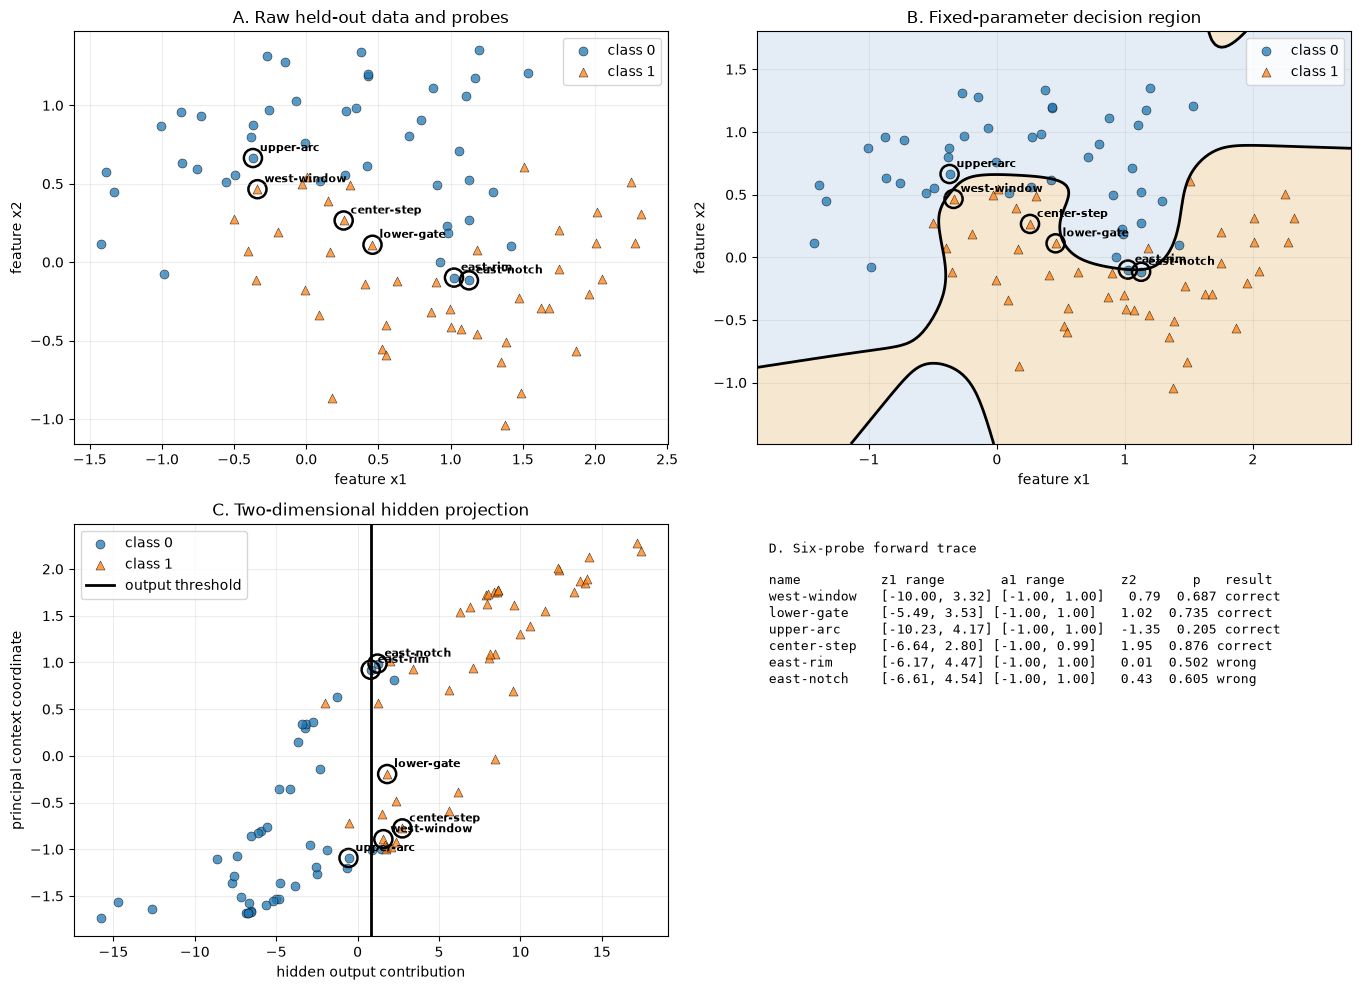

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

scatter_classes(axes[0, 0], X_evidence, y_evidence, "A. Raw held-out data and probes")
annotate_probes(axes[0, 0], X_probes)

axes[0, 1].contourf(xx1, xx2, mesh_predictions, levels=[-0.5, 0.5, 1.5], colors=["#d9e6f2", "#f3ddbd"], alpha=0.7)
axes[0, 1].contour(xx1, xx2, mesh_cache['P'].reshape(xx1.shape), levels=[0.5], colors="black", linewidths=2)
scatter_classes(axes[0, 1], X_evidence, y_evidence, "B. Fixed-parameter decision region")
annotate_probes(axes[0, 1], X_probes)

scatter_classes(axes[1, 0], evidence_hidden_2d, y_evidence, "C. Two-dimensional hidden projection")
annotate_probes(axes[1, 0], probe_hidden_2d)
axes[1, 0].axvline(-parameters['b2'][0], color="black", linewidth=2, label="output threshold")
axes[1, 0].set(xlabel="hidden output contribution", ylabel="principal context coordinate")
axes[1, 0].legend()

axes[1, 1].axis('off')
trace_lines = ["D. Six-probe forward trace", "", "name          z1 range       a1 range       z2       p   result"]
for row, name in enumerate(probe_names):
    result = "correct" if probe_correct[row] else "wrong"
    trace_lines.append(
        f"{name:<13} [{probe_cache['Z1'][row].min():>5.2f},{probe_cache['Z1'][row].max():>5.2f}] "
        f"[{probe_cache['A1'][row].min():>5.2f},{probe_cache['A1'][row].max():>5.2f}] "
        f"{probe_cache['Z2'][row, 0]:>6.2f} {probe_cache['P'][row, 0]:>6.3f} {result}"
    )
axes[1, 1].text(0.02, 0.96, '\n'.join(trace_lines), va='top', family='monospace', fontsize=9)

plt.tight_layout()
plt.show()

## Diagnose the Mystery

For one correct and one incorrect probe, trace raw location -> hidden range/projection -> output logit -> sigmoid output -> thresholded class. State which evidence changed or strengthened your original prediction.

Classify each event as an implementation/interface failure, a semantic-invariant failure, or a complete fixed-parameter prediction that disagrees with the target. State what this forward evidence cannot reveal about how the parameters were obtained.

In [13]:
correct_name = probe_names[np.flatnonzero(probe_correct)[0]]
wrong_name = probe_names[np.flatnonzero(~probe_correct)[0]]
correct_row = int(np.flatnonzero(probe_names == correct_name)[0])
wrong_row = int(np.flatnonzero(probe_names == wrong_name)[0])
mystery_diagnosis = {
    "one_correct_trace": f"{correct_name}: valid hidden range, z2={probe_cache['Z2'][correct_row,0]:.3f}, p={probe_cache['P'][correct_row,0]:.3f}, threshold class matches target.",
    "one_incorrect_trace": f"{wrong_name}: complete valid trace gives z2={probe_cache['Z2'][wrong_row,0]:.3f}, p={probe_cache['P'][wrong_row,0]:.3f}, but threshold class disagrees with target.",
    "prediction_revision": "The decision contour and generated probabilities replace raw proximity with evidence from the actual fixed computation.",
    "transpose_failure_type": "Implementation/interface failure: incompatible inner dimensions prevent hidden activations.",
    "wrong_probe_failure_type": "Complete fixed-parameter prediction error: every shape/range check passes, but target and class differ.",
    "forward_evidence_limit": "The trace shows how fixed values produced outputs, not why offline fitting selected them, whether outputs are calibrated, or complete six-dimensional causality.",
}
assert all(value.strip() for value in mystery_diagnosis.values())
for key, value in mystery_diagnosis.items():
    print(f"{key}: {value}")


one_correct_trace: west-window: valid hidden range, z2=0.786, p=0.687, threshold class matches target.
one_incorrect_trace: east-rim: complete valid trace gives z2=0.009, p=0.502, but threshold class disagrees with target.
prediction_revision: The decision contour and generated probabilities replace raw proximity with evidence from the actual fixed computation.
transpose_failure_type: Implementation/interface failure: incompatible inner dimensions prevent hidden activations.
wrong_probe_failure_type: Complete fixed-parameter prediction error: every shape/range check passes, but target and class differ.
forward_evidence_limit: The trace shows how fixed values produced outputs, not why offline fitting selected them, whether outputs are calibrated, or complete six-dimensional causality.


### Instructor Four-Panel Debrief

**What happened?** Raw geometry suggested risky probes; the decision region identified the actual side,
the hidden projection showed an output-aligned separation for most points, and the trace supplied exact
logits/probabilities.  
**Why?** Each panel exposes a different stage of the same fixed forward computation.  
**Concept:** Diagnosis should reconcile geometry, representation, numeric trace, and decision rule.

**Observation to point out:** The vertical line in the hidden panel is the output threshold on an
output-aligned coordinate. The second axis is contextual. The projection is useful evidence, not a
complete explanation of six hidden dimensions.


## Extend: One Copied-Parameter Perturbation

Choose exactly one element from `W1`, `b1`, `W2`, or `b2` and a nonzero delta. Before running, predict a local effect on at least one probe probability or boundary region. The experiment operates on a deep copy; the canonical parameters must remain unchanged.

In [14]:
perturbation = {
    "parameter": "b2",
    "index": (0,),
    "delta": 0.20,
    "predicted_local_effect": "Increasing output bias should increase every probe logit and probability; near-threshold classes may flip.",
}
assert perturbation["parameter"] in parameters
assert isinstance(perturbation["index"], tuple)
assert abs(float(perturbation["delta"])) >= 0.05
assert perturbation["predicted_local_effect"].strip()
assert len(perturbation["index"]) == parameters[perturbation["parameter"]].ndim

perturbed_parameters = copy.deepcopy(parameters)
perturbed_parameters[perturbation["parameter"]][perturbation["index"]] += float(perturbation["delta"])


In [15]:
perturbed_evidence_cache = batch_forward(X_evidence, perturbed_parameters)
perturbed_probe_cache = batch_forward(X_probes, perturbed_parameters)
perturbed_predictions = predict_classes(perturbed_evidence_cache['P'])
perturbed_probe_predictions = predict_classes(perturbed_probe_cache['P'])
probability_shift = perturbed_probe_cache['P'].ravel() - probe_cache['P'].ravel()

print(f"Changed {perturbation['parameter']}{perturbation['index']} by {float(perturbation['delta']):+.3f}")
print(f"Held-out accuracy: baseline={evidence_accuracy:.4f}, perturbed={np.mean(perturbed_predictions == y_evidence):.4f}")
for name, shift, old_class, new_class in zip(probe_names, probability_shift, probe_predictions, perturbed_probe_predictions):
    print(f"{name:<14} probability_shift={shift:+.4f} class {old_class} -> {new_class}")
assert any(not np.array_equal(parameters[name], perturbed_parameters[name]) for name in parameters)
assert all(np.array_equal(parameters[name], parameter_snapshot[name]) for name in parameters)
assert not np.allclose(perturbed_probe_cache['P'], probe_cache['P'])

Changed b2(0,) by +0.200
Held-out accuracy: baseline=0.9111, perturbed=0.9111
west-window    probability_shift=+0.0413 class 1 -> 1
lower-gate     probability_shift=+0.0371 class 1 -> 1
upper-arc      probability_shift=+0.0345 class 0 -> 0
center-step    probability_shift=+0.0202 class 1 -> 1
east-rim       probability_shift=+0.0498 class 1 -> 1
east-notch     probability_shift=+0.0466 class 1 -> 1


### Instructor Answer: Controlled Perturbation

**What happened?** `b2 + 0.20` increases all six logits and probabilities; the exact table records any
class flips. Canonical held-out accuracy remains `0.9111` in the reference run.  
**Why?** Output bias adds the same logit shift after hidden computation, while sigmoid converts equal
logit changes into unequal probability changes depending on starting value.  
**Concept:** A copied one-parameter intervention supports local attribution and preserves baseline evidence.

Alternative valid perturbations are acceptable if exactly one indexed parameter changes, the prediction
names a local observable, and canonical arrays remain byte-for-byte unchanged.


## Explain and Reflect

Complete the final evidence record:

1. Did the perturbation support your local prediction? Cite a probability or class change.
2. Why do fixed parameters, rather than an inference-time learning process, produce every result in this notebook?
3. What would Day 2 need to add for an incorrect example to influence future parameters?
4. Why is the two-dimensional hidden projection useful but incomplete?

In [16]:
reflection = {
    "perturbation_result": "Supported: b2 +0.20 increased every probe probability; the printed shifts quantify the local effect.",
    "fixed_parameter_mechanism": "Every baseline output is produced by the supplied arrays and tanh/sigmoid transformations; no assignment updates parameters during inference.",
    "day2_missing_piece": "Learning needs a scalar error/loss, parameter sensitivities/gradients, and an update rule repeated over data.",
    "projection_limit": "Two plotted coordinates summarize six hidden dimensions and can omit distances or relationships present in the full activation vector.",
}
assert all(value.strip() for value in reflection.values())
assert 0.82 <= evidence_accuracy <= 0.92
assert evidence_cache["A1"].shape == (90, 6) and evidence_cache["P"].shape == (90, 1)
assert np.sum(probe_correct) == 4 and np.sum(~probe_correct) == 2
assert transpose_failure_observed
assert np.array_equal(predict_classes(batch_forward(mesh_X, parameters)["P"]), mesh_predictions.ravel())
assert all(np.array_equal(parameters[name], parameter_snapshot[name]) for name in parameters)
print("LAB-D1-04 checkpoint passed: held-out band, shapes/ranges, 4/2 probes, mesh parity, transpose recovery, and parameter immutability.")


LAB-D1-04 checkpoint passed: held-out band, shapes/ranges, 4/2 probes, mesh parity, transpose recovery, and parameter immutability.


## Troubleshooting

| Symptom | Likely cause | Recovery |
|---|---|---|
| Prediction checkpoint stops | Two names or a shape/evidence response is missing | Complete the commitment before revealing parameters |
| Hidden matrix multiplication fails | `W1` was transposed or examples are not rows | Restore `(n,2) @ (2,6)` |
| Output is `(n,)` instead of `(n,1)` | A singleton dimension was squeezed too early | Keep `W2` `(6,1)` and `b2` `(1,)` until class conversion |
| Probabilities overflow | Sigmoid used an unstable direct exponent | Branch by sign or use an equivalent stable formula |
| Probe behavior differs | Seed, split, probe indices, or fixed values changed | Restart and rerun supplied setup unchanged |
| Visualization checkpoint stops | Mesh or hidden assignments remain `None` | Call the named helpers with canonical parameters/cache values |
| Perturbation mutates baseline | The canonical dictionary was edited | Restart and use `copy.deepcopy(parameters)` |

## Optional Extension: Opposite Output-Bias Delta

Apply `-0.20` to the same copied `b2` element. Predict that logits/probabilities decrease, but do not
assume probability shifts are exactly symmetric because sigmoid is nonlinear.


In [17]:
opposite_parameters = copy.deepcopy(parameters)
opposite_parameters["b2"][(0,)] -= 0.20
opposite_probe_cache = batch_forward(X_probes, opposite_parameters)
opposite_shift = opposite_probe_cache["P"].ravel() - probe_cache["P"].ravel()
assert np.all(opposite_shift < 0.0)
assert np.all(probability_shift > 0.0)
assert all(np.array_equal(parameters[name], parameter_snapshot[name]) for name in parameters)
print("positive-delta probability shifts:", np.round(probability_shift, 6))
print("negative-delta probability shifts:", np.round(opposite_shift, 6))
print("perfectly symmetric:", np.allclose(probability_shift, -opposite_shift))


positive-delta probability shifts: [0.041332 0.037103 0.034547 0.020173 0.049811 0.046643]
negative-delta probability shifts: [-0.04453  -0.040748 -0.030713 -0.02344  -0.049855 -0.048644]
perfectly symmetric: False


### Instructor Extension Answer

**What happened?** The opposite delta lowers every probability, while positive and negative probability
shifts are not generally exact mirror images.  
**Why?** Logit shifts are symmetric, but sigmoid slope varies with the starting logit.  
**Concept:** Nonlinear output transformations make equal parameter changes produce state-dependent
probability effects.

## Takeaways

- A vectorized `2 -> 6 -> 1` pass yields hidden `(n,6)` and output `(n,1)`.
- Exact reference evidence is `0.9111` held-out accuracy and four correct/two wrong named probes.
- A transpose exception is an interface failure; a completed wrong class is a prediction error.
- Raw, decision, hidden, and trace evidence answer different diagnostic questions.
- Day 2 must add loss, gradients, and updates; Day 1 inference never changes parameters.


## Instructor Operations and Recovery

**Dependency/import issues:** Confirm the selected kernel contains NumPy and matplotlib; Labs 2 and 4
also require scikit-learn. Run the version cell first after any install, restart the kernel, and rerun
from the top. Day 1 uses no network data.

**Shape/order issues:** Print operand shapes at the failing matrix multiplication and compare them with
the batch-first contract. A passing shape is not enough for softmax or threshold semantics, so rerun the
stated invariant too. Never continue after running cells out of order; restart and Run All.

**Unexpected metrics/random differences:** Restore the canonical seed, supplied data, explicit estimator
settings, and fixed parameter arrays. Treat documented metric bands as checks and deterministic reference
values as evidence for this exact setup. Do not tune around a changed environment during a live class.

**Plotting/runtime/memory:** If plots do not display, restart the backend/kernel and rerun imports. If a
live render is slow, use the stored output and keep the prediction/debrief. These notebooks use small
arrays and are CPU practical; GPU changes neither the required evidence nor the explanation.

**Colab:** Select a CPU runtime. Package pins are documented in `courseware/shared/environment.md`, but a
hosted Colab run remains a separate validation claim. Do not describe local execution as Colab validation.


    **Lab-specific stuck points:** If the 4/2 pattern changes, stop and restore seed `41`, split, probe indices,
    and fixed arrays; do not improvise new parameters. If the four-panel plot fails, use the stored probe
    table and cached output. Keep the canonical dictionary immutable. An alternative hidden projection is
    acceptable only when point identity is preserved and its information-loss limitation is stated.
